In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_store=pd.read_csv("clean_store.csv")
df_customer=pd.read_csv("cleaned_customer.csv")
df_product=pd.read_csv("cleaned_product.csv")
df_sales=pd.read_csv("cleaned_sales.csv")

In [6]:
df_store.dropna(subset="store_id",inplace=True)
df_store["country"].unique()

<ArrowStringArray>
['USA', 'Australia', 'Germeny', 'UK', 'Canada', 'France']
Length: 6, dtype: str

In [7]:
df_customer

,customer_id,age,gender,loyalty_member,join_date
0,C000002,47,Male,0,2021-12-26
1,C000003,58,Female,1,2022-09-13
2,C000006,32,Male,0,2022-05-22
3,C000007,51,Male,1,2024-07-28
4,C000008,56,Female,0,2024-08-12
...,...,...,...,...,...
7219,C009545,23,Female,0,2024-02-24
7220,C009547,24,Female,1,2025-05-26
7221,C009548,39,Male,0,2025-12-30
7222,C009551,70,Male,1,2024-11-21


In [5]:
df_sales

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40
...,...,...,...,...,...,...,...,...,...,...,...
4519,0RD00004520,2023-01-08,P0193,S095,C016438,2,14.76,0.00,29.52,15.89,13.63
4520,0RD00004521,2024-08-28,P0132,S024,C012788,5,13.06,0.20,52.24,28.73,23.51
4521,0RD00004522,2023-02-16,P0023,S062,C017964,4,8.07,0.20,25.82,16.17,9.65
4522,0RD00004523,2023-03-20,P0114,S027,C037648,2,14.68,0.15,24.96,13.27,11.68


# data cleaning and data inspection

In [8]:
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 4524 entries, 0 to 4523
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     4524 non-null   str    
 1   order_date   4524 non-null   str    
 2   product_id   4524 non-null   str    
 3   store_id     4524 non-null   str    
 4   customer_id  4524 non-null   str    
 5   quantity     4524 non-null   int64  
 6   unit_price   4524 non-null   float64
 7   discount     4524 non-null   float64
 8   revenue      4524 non-null   float64
 9   cost         4524 non-null   float64
 10  profit       4524 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 552.4 KB


In [9]:
df_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 7224 entries, 0 to 7223
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     6583 non-null   str  
 1   age             7224 non-null   int64
 2   gender          7197 non-null   str  
 3   loyalty_member  7224 non-null   int64
 4   join_date       7184 non-null   str  
dtypes: int64(2), str(3)
memory usage: 435.2 KB


In [10]:
df_product.info()

<class 'pandas.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     129 non-null    str  
 1   product_name   125 non-null    str  
 2   brand          127 non-null    str  
 3   category       129 non-null    str  
 4   cocoa_percent  129 non-null    int64
 5   weight_g       129 non-null    int64
dtypes: int64(2), str(4)
memory usage: 10.6 KB


In [23]:
#merging the salees data to customer by using inner
df_cs_sales=df_sales.merge(df_customer[['customer_id', 'age', 'gender']],on='customer_id',how="inner")

In [12]:
#merging sales data to the store data by using inner merging
df_st_sales=df_sales.merge(df_store[['store_id', 'store_name', 'city', 'country']],on="store_id",how="inner")

In [11]:
#merging sales data to rpoduct data by using inner mergin
d_produ_sales=df_sales.merge(df_product[['product_id', 'product_name', 'brand', 'category']],on='product_id',how="inner")

In [12]:
df_st_sales

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,store_name,city,country
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,Chocolate Store 93,Sydney,Australia
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,Chocolate Store 65,New York,USA
2,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,Chocolate Store 88,Toronto,Canada
3,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,Chocolate Store 54,London,UK
4,0RD00000006,2024-03-29,P0160,S089,C008918,4,13.52,0.00,54.08,36.59,17.49,Chocolate Store 89,Toronto,Canada
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3427,0RD00004518,2024-01-08,P0161,S046,C007980,4,11.68,0.00,46.72,25.15,21.57,Chocolate Store 46,London,UK
3428,0RD00004520,2023-01-08,P0193,S095,C016438,2,14.76,0.00,29.52,15.89,13.63,Chocolate Store 95,Toronto,Canada
3429,0RD00004521,2024-08-28,P0132,S024,C012788,5,13.06,0.20,52.24,28.73,23.51,Chocolate Store 24,NaN,France
3430,0RD00004522,2023-02-16,P0023,S062,C017964,4,8.07,0.20,25.82,16.17,9.65,Chocolate Store 62,Toronto,Canada


In [32]:
df_sales["order_date"]=pd.to_datetime(df_sales["order_date"])

## EDA exploratory

In [33]:
#descriptive statistics
df_sales.describe()

,order_date,quantity,unit_price,discount,revenue,cost,profit
count,4524,4524.000000,4524.000000,4524.000000,4524.000000,4524.000000,4524.000000
mean,2023-12-30 07:37:24.031830,2.985411,9.046393,0.055393,25.412224,15.274485,10.137816
min,2023-01-01 00:00:00,1.000000,3.000000,0.000000,2.550000,1.490000,0.870000
25%,2023-06-28 00:00:00,2.000000,6.100000,0.000000,12.340000,7.307500,4.850000
50%,2023-12-26 00:00:00,3.000000,9.070000,0.000000,22.165000,13.245000,8.670000
75%,2024-06-29 00:00:00,4.000000,11.982500,0.100000,35.680000,21.290000,13.922500
max,2024-12-31 00:00:00,5.000000,15.000000,0.200000,75.000000,52.370000,37.230000
std,NaN,1.400628,3.425260,0.076433,16.023722,9.818302,6.592831


In [34]:
#checking the correlation between numeric numbers
df_sales.corr(numeric_only=True)

,quantity,unit_price,discount,revenue,cost,profit
quantity,1.000000,-0.016877,0.004246,0.733131,0.721548,0.707306
unit_price,-0.016877,1.000000,0.013021,0.588152,0.577488,0.569476
discount,0.004246,0.013021,1.000000,-0.113433,-0.110985,-0.110398
revenue,0.733131,0.588152,-0.113433,1.000000,0.984244,0.964706
cost,0.721548,0.577488,-0.110985,0.984244,1.000000,0.902946
profit,0.707306,0.569476,-0.110398,0.964706,0.902946,1.000000


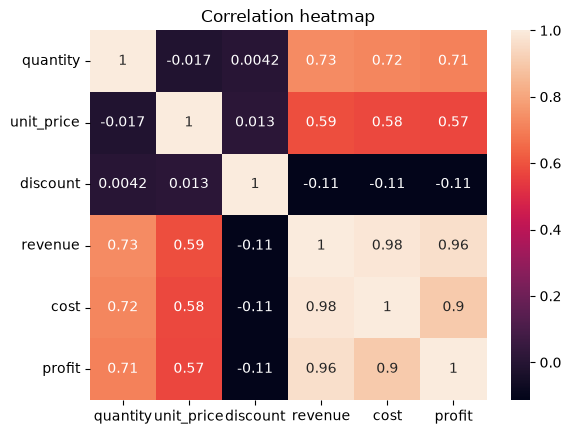

In [35]:
#correlation heatmap
sns.heatmap(df_sales.corr(numeric_only=True),annot=True)
plt.title("Correlation heatmap")
plt.rcParams["figure.figsize"]=(20,7)
plt.show()

In [16]:
total=pd.DataFrame(df_sales[["revenue","cost","profit"]].sum())
total

,0
revenue,114964.90
cost,69101.77
profit,45863.48


#### TOtal amount by revenue cost and profit
* Total revenue generated by the company is 114,964.94
* Total cost of the company was 69,101.77
* Total profit generated by the company was 45,863.48

In [24]:
gen_df=((df_cs_sales.groupby("gender")[["revenue","cost","profit"]].sum(numeric_only=True)/df_cs_sales[["revenue","cost","profit"]].sum())*100).round(2)
gen_df

,revenue,cost,profit
gender,,,
Female,45.79,45.58,46.11
Male,53.69,53.83,53.48


### revenue cost and profit base on the custommer data we have
* 45.79% of the revenue have been generated by female and the 53.69% have been generated by the male
* female product  costed 45.58% of the total and the male product 53.83%
* 46.11% of the profit have been generate by the female and 53.48% of teh profit have been generated by the male



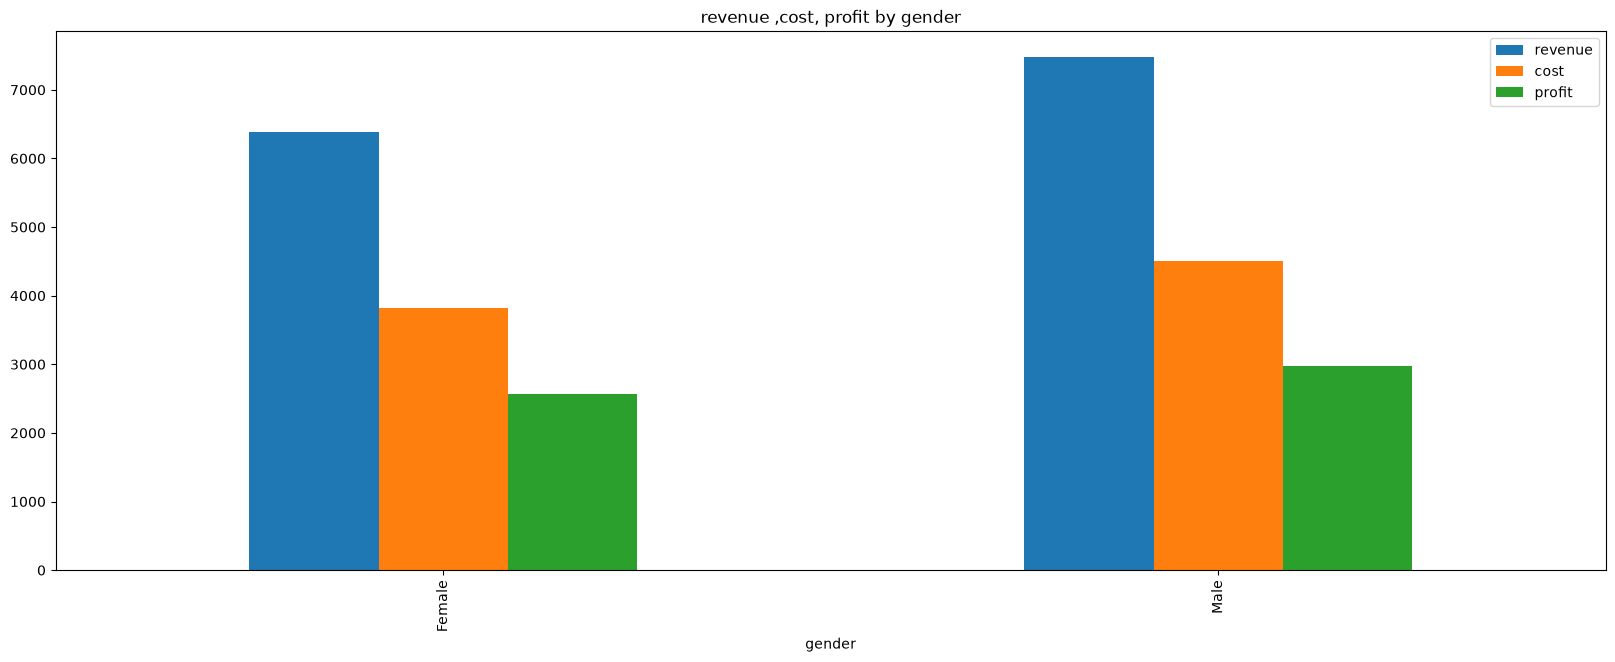

In [37]:
(df_cs_sales.groupby("gender")[["revenue","cost","profit"]].sum(numeric_only=True)).plot.bar(title="revenue ,cost, profit by gender")
plt.show()

In [25]:
cou_df=(df_st_sales.groupby("country")[["revenue","cost","profit"]].sum(numeric_only=True)).sort_values("revenue",ascending=False)
cou_df

,revenue,cost,profit
country,,,
Australia,25678.50,15424.78,10253.62
Canada,20878.20,12602.02,8276.23
UK,17652.00,10651.29,7000.96
USA,11932.82,7175.75,4757.04
Germeny,8702.33,5247.24,3455.17
France,2167.65,1276.02,891.64


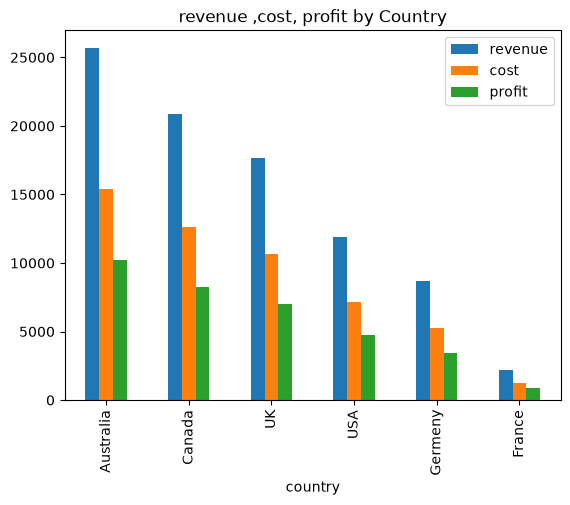

In [26]:
cou_df.plot.bar(title="revenue ,cost, profit by Country")
plt.show()

In [27]:
cou_df_per=((df_st_sales.groupby("country")[["revenue","cost","profit"]].sum(numeric_only=True)/df_st_sales[["revenue","cost","profit"]].sum())*100).round(2)
cou_df_per

,revenue,cost,profit
country,,,
Australia,29.51,29.45,29.61
Canada,23.99,24.06,23.90
France,2.49,2.44,2.57
Germeny,10.00,10.02,9.98
UK,20.29,20.34,20.21
USA,13.71,13.70,13.73


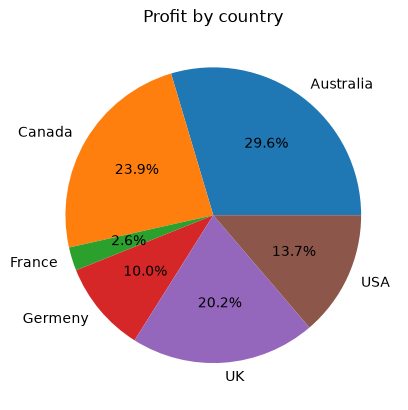

In [28]:
cou_df_per["profit"].plot.pie(subplots=True ,autopct='%1.1f%%')
plt.title("Profit by country")
plt.show()

## profit by country
* Autralia have generated 29.6% of the profit 
* Canada have generated 23.9% of the profit
* UK have generated 20.2% of the profit
* USA have generated 13.7%% of the profit
* Germeny have generated 10% of the profit
* France have generated 2.6% of the profit

In [38]:
df_sales["purchase_year"]=df_sales["order_date"].dt.year

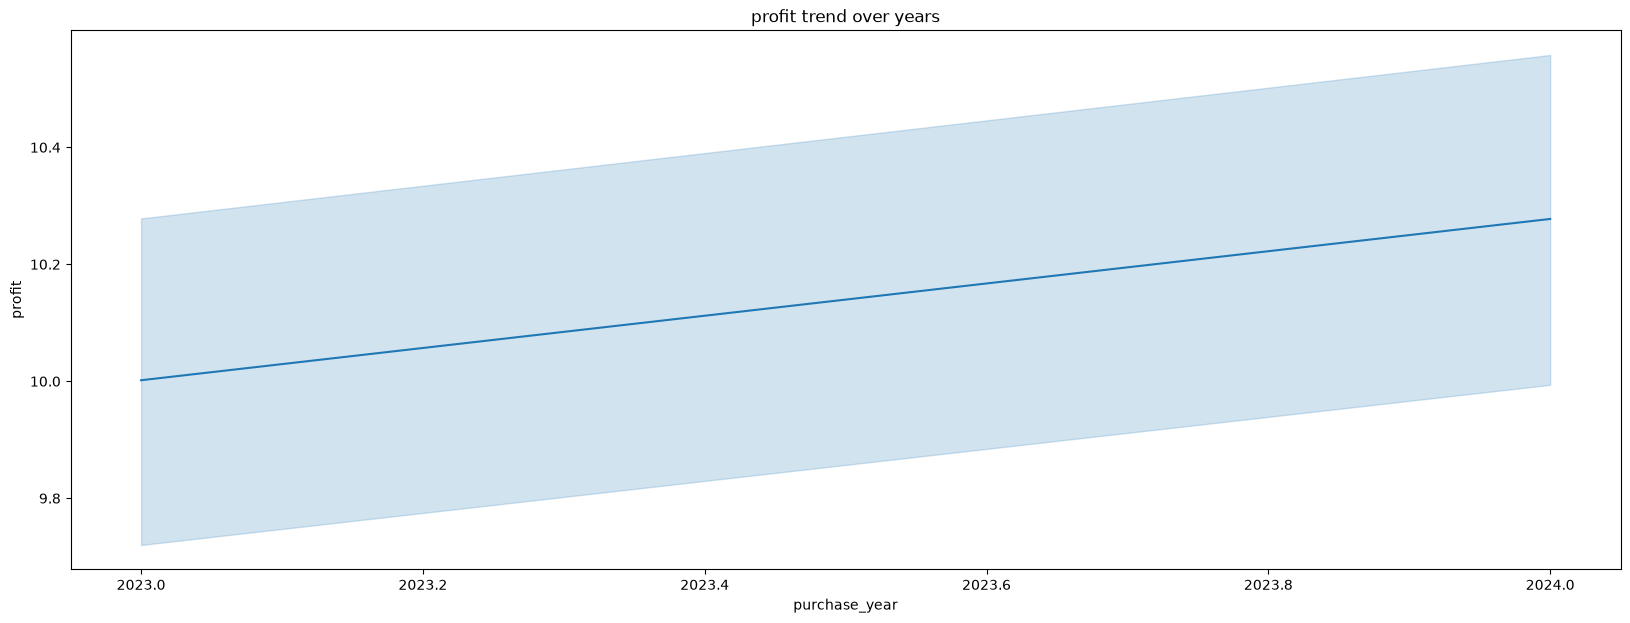

In [39]:
sns.lineplot(df_sales,x="purchase_year",y="profit")
plt.title("profit trend over years")
plt.show()

In [40]:
df_sales["purchased_month"]=df_sales["order_date"].dt.month

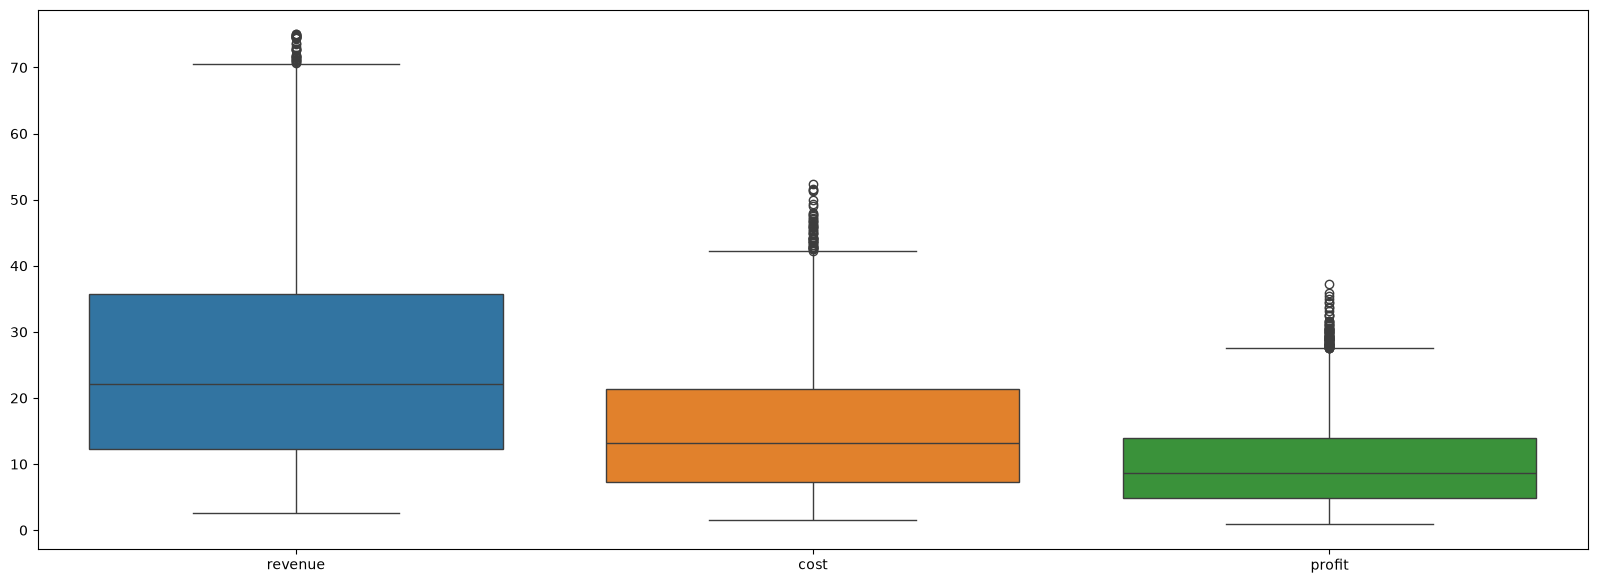

In [41]:
sns.boxplot(df_sales[["revenue","cost","profit"]])
plt.show()

In [42]:
cust_pr=pd.DataFrame(df_sales.groupby("order_date")["order_id"].count())
cust_pr

,order_id
order_date,
2023-01-01,5
2023-01-02,7
2023-01-03,2
2023-01-04,5
2023-01-05,3
...,...
2024-12-27,8
2024-12-28,6
2024-12-29,6


In [43]:
cust_pr.reset_index(inplace=True)
cust_pr

,order_date,order_id
0,2023-01-01,5
1,2023-01-02,7
2,2023-01-03,2
3,2023-01-04,5
4,2023-01-05,3
...,...,...
726,2024-12-27,8
727,2024-12-28,6
728,2024-12-29,6
729,2024-12-30,7


In [44]:
cust_pr.rename(columns={"order_id":"customer_nb"},inplace=True)

In [103]:
cust_pr["year"]=cust_pr["order_date"].dt.year
cust_pr["month"]=cust_pr["order_date"].dt.month
cust_pr["day"]=cust_pr["order_date"].dt.day
cust_pr["day_of_the_week"]=cust_pr["order_date"].dt.day_of_week


In [104]:
cust_pr=cust_pr.sort_values("order_date",ascending=True)

In [105]:
cust_pr["lag1"]=cust_pr["customer_nb"].shift(1)
cust_pr["lag2"]=cust_pr["customer_nb"].shift(2)
cust_pr["lag7"]=cust_pr["customer_nb"].shift(7)
cust_pr["lag14"]=cust_pr["customer_nb"].shift(14)
cust_pr["lag28"]=cust_pr["customer_nb"].shift(28)


In [106]:
cust_pr.dropna(inplace=True)

In [127]:
targets='customer_nb'
inputs=[ 'year', 'month', 'day_of_the_week','day', 'lag1', 'lag2',
       'lag7', 'lag14', 'lag28']

In [108]:

train_size=int(len(cust_pr)*0.7)
test_size=int(len(cust_pr)*0.3)

train_df=cust_pr.iloc[:train_size]
test_df=cust_pr.iloc[train_size:]



In [109]:
train_df

,order_date,customer_nb,year,month,day,lag1,lag2,lag7,lag14,lag28,day_of_the_week
84,2023-03-26,6,2023,3,26,5.0,5.0,7.0,11.0,13.0,6
85,2023-03-27,6,2023,3,27,6.0,5.0,10.0,6.0,3.0,0
86,2023-03-28,5,2023,3,28,6.0,6.0,6.0,9.0,8.0,1
87,2023-03-29,4,2023,3,29,5.0,6.0,3.0,9.0,4.0,2
88,2023-03-30,1,2023,3,30,4.0,5.0,8.0,5.0,5.0,3
...,...,...,...,...,...,...,...,...,...,...,...
531,2024-06-15,5,2024,6,15,4.0,3.0,7.0,10.0,3.0,5
532,2024-06-16,6,2024,6,16,5.0,4.0,7.0,1.0,8.0,6
533,2024-06-17,6,2024,6,17,6.0,5.0,4.0,5.0,8.0,0
534,2024-06-18,4,2024,6,18,6.0,6.0,5.0,8.0,7.0,1


In [110]:
#inputs creation
train_inputs=train_df[inputs].copy()

test_inputs=test_df[inputs].copy()
#target creation
train_target=train_df[targets].copy()

test_target=test_df[targets].copy()


In [111]:
print(train_df.shape)

print(test_df.shape)

(452, 11)
(195, 11)


In [112]:
from xgboost import XGBRegressor

In [113]:
params={
    "max_depth":[2,3,4,5,6,7,8,9,10],
    "n_estimators":[50,100,200],
    "learning_rate":[0.1,1.1,0.2,1.5]
}

In [114]:
from sklearn.model_selection import RandomizedSearchCV

In [115]:
rd=RandomizedSearchCV(XGBRegressor(random_state=42,n_jobs=-1),params).fit(train_inputs,train_target)

In [116]:
model=rd.best_estimator_

In [117]:
train_preds=model.predict(train_inputs)

In [118]:
from sklearn.metrics import root_mean_squared_error,mean_absolute_error
print(f"RMSE {root_mean_squared_error(train_preds,train_target)}")
print(f"MAE {mean_absolute_error(train_preds,train_target)}")

RMSE 1.7265294790267944
MAE 1.363497018814087


In [119]:
feature=pd.DataFrame({
    "feature":train_inputs.columns,
    "importances":model.feature_importances_
}).sort_values("importances",ascending=False)

feature.head(10)

,feature,importances
2,day_of_the_week,0.146237
5,lag2,0.131817
6,lag7,0.122398
0,year,0.112244
4,lag1,0.109228
3,day,0.108041
8,lag28,0.107484
1,month,0.087174
7,lag14,0.075377


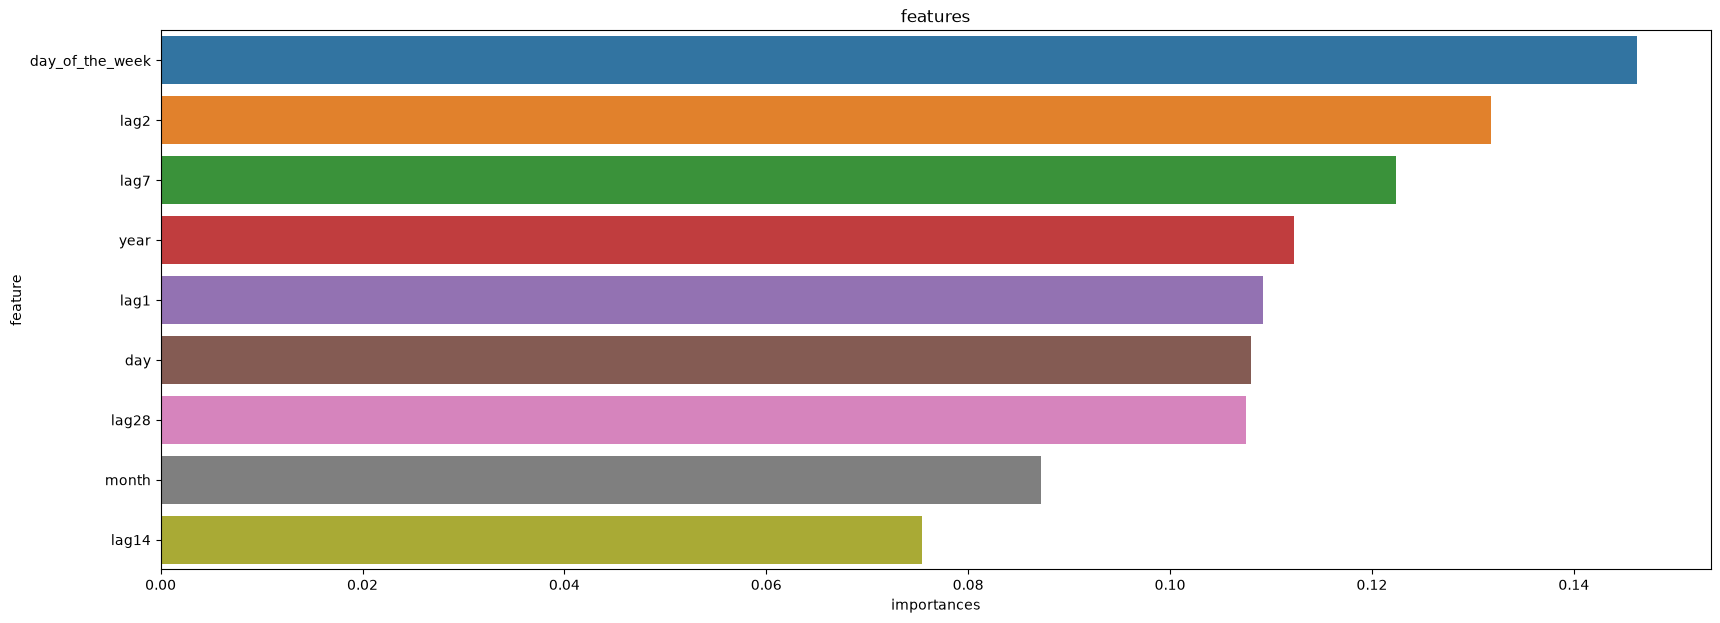

In [120]:
sns.barplot(feature,x="importances",y="feature",hue="feature")
plt.title("features")
plt.show()

In [121]:
test_preds=model.predict(test_inputs)
print(f" RMSE: {root_mean_squared_error(test_preds,test_target)}")
print(f" MAE: {mean_absolute_error(test_preds,test_target)}")

 RMSE: 2.255943536758423
 MAE: 1.8404462337493896


In [165]:
def customer_number(inputs):
    df=pd.DataFrame(inputs)
    
    preds=model.predict(df)[0]
    return preds

In [101]:
cust_pr[inputs].tail(10).to_json("customer.json")

In [161]:
input=[{
    'year':2024,
    'month':12,
    'day_of_the_week':6,
    'day':22,
    'lag1':7,
    'lag2':6,
    'lag7':10,
    'lag14':4,
    'lag28':4
}]

In [166]:
customer_number(input)

np.float32(5.9519978)

In [164]:
model.predict(pd.DataFrame(input))

array([5.9519978], dtype=float32)